In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nibhakumari32/sales-dataset-exam-1/sales_dataset.csv')

In [3]:
df.head(20)

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,405-8078784-5731545,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN
5,404-1490984-4578765,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,...,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
6,408-5748499-6859555,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,XL,...,1,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
7,406-7807733-3785945,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,...,1,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
8,407-5443024-5233168,4/30/2022,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,...,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
9,402-4393761-0311520,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,XXL,...,1,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [5]:
df.isnull().sum()

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6871
Qty                       0
currency               7794
Amount                 7794
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49142
B2B                       0
fulfilled-by          89679
dtype: int64

In [6]:
df[df.duplicated(['Order ID','ASIN'], keep=False)]


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
30651,406-0372545-6086735,4/12/2022,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,...,0,NaN,NaN,Siliguri,WEST BENGAL,734008.0,IN,NaN,False,NaN
30652,406-0372545-6086735,4/12/2022,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,...,0,NaN,NaN,Siliguri,WEST BENGAL,734008.0,IN,NaN,False,NaN
41282,408-0373839-4433120,4/5/2022,Cancelled,Amazon,Amazon.in,Expedited,JNE3501,JNE3501-KR-M,kurta,M,...,0,NaN,NaN,BENGALURU,KARNATAKA,560072.0,IN,NaN,False,NaN
41283,408-0373839-4433120,4/5/2022,Cancelled,Amazon,Amazon.in,Expedited,JNE3501,JNE3501-KR-M,kurta,M,...,0,NaN,NaN,BENGALURU,KARNATAKA,560072.0,IN,NaN,False,NaN
52321,407-8364731-6449117,5/29/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3769,JNE3769-KR-L,kurta,L,...,0,NaN,NaN,Theni,TAMIL NADU,625579.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
52324,407-8364731-6449117,5/29/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3769,JNE3769-KR-L,kurta,L,...,1,INR,487.0,Theni,TAMIL NADU,625579.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
79835,171-9628368-5329958,5/7/2022,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,...,0,NaN,NaN,ERNAKULAM,KERALA,682017.0,IN,NaN,False,NaN
79836,171-9628368-5329958,5/7/2022,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,...,0,NaN,NaN,ERNAKULAM,KERALA,682017.0,IN,NaN,False,NaN
85781,171-3249942-2207542,5/3/2022,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,...,1,INR,939.0,PUNE,MAHARASHTRA,411057.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
85782,171-3249942-2207542,5/3/2022,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,...,1,INR,939.0,PUNE,MAHARASHTRA,411057.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN


In [7]:
df.drop_duplicates(['Order ID','ASIN'],inplace = True)

In [8]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
print(df["Date"].dtype)


datetime64[ns]


In [9]:
 df["Courier Status"] = df["Courier Status"].fillna("Unknown")

In [10]:
df["currency"] = df["currency"].fillna("INR")

In [11]:
df["Amount"] = df["Amount"].fillna(df["Amount"].median())

In [12]:
df["ship-city"] = df["ship-city"].fillna("Unknown")

In [13]:
df["ship-state"] = df["ship-state"].fillna("Unknown")

In [14]:
df["ship-country"] = df["ship-country"].fillna("Unknown")

In [15]:
 df["ship-postal-code"] = df["ship-postal-code"].fillna(df["ship-postal-code"].mode()[0])

In [16]:
df["promotion-ids"] = df["promotion-ids"].fillna("No Promotion")


In [17]:
df["fulfilled-by"] = df["fulfilled-by"].fillna("Unknown")

In [18]:
df.isnull().sum()

Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
promotion-ids         0
B2B                   0
fulfilled-by          0
dtype: int64

### Financial Performance Analysis

In [19]:
## Analyze total revenue growth over time.

df['month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['Amount'].sum()
print(monthly_revenue)

month
2022-03      107128.85
2022-04    30646525.96
2022-05    27734563.75
2022-06    24797387.38
Freq: M, Name: Amount, dtype: float64


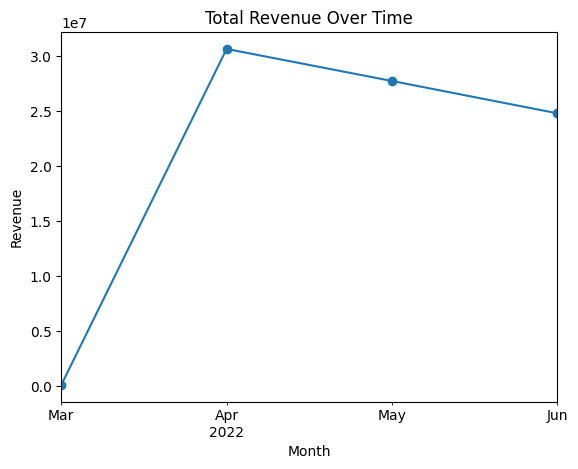

In [20]:
monthly_revenue.plot(kind='line', marker='o', title='Total Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

Key Inisght-- Revenue increased sharply from March to April, reaching its highest value in April (₹3.06M). After April, revenue showed a gradual decline in May and June, indicating a slowdown in sales. March had the lowest revenue, likely due to incomplete monthly data.

In [29]:
## Identifying best-selling products and seasonal sales trends
best_sellers = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print("Top selling products:",best_sellers)


Top selling products: Category
Set              41154789.67
kurta            23204097.70
Western Dress    11694003.69
Top               5623727.30
Ethnic Dress       830292.66
Blouse             485633.18
Bottom             162767.98
Saree              129378.76
Dupatta               915.00
Name: Amount, dtype: float64


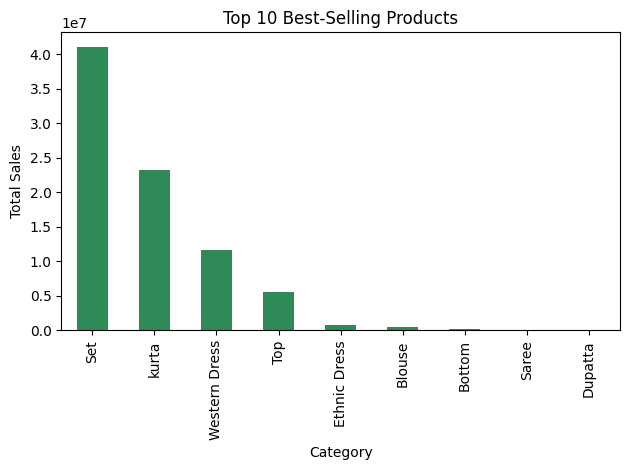

In [31]:
best_sellers.head(10).plot(kind='bar', title='Top 10 Best-Selling Products', color='seagreen')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Key Insight-- JNE13797-KR-L is the highest revenue-generating SKU.
A few top SKUs contribute a major share of total sales.
These products should be prioritized for inventory and promotions.

In [23]:
df['Month'] = df['Date'].dt.month_name()
       
seasonal_sales = df.groupby('Month')['Amount'].sum()
month_order = ['March', 'April', 'May', 'June']
seasonal_sales = seasonal_sales.reindex(month_order)     

print("Sales by month:",seasonal_sales)

Sales by month: Month
March      107128.85
April    30646525.96
May      27734563.75
June     24797387.38
Name: Amount, dtype: float64


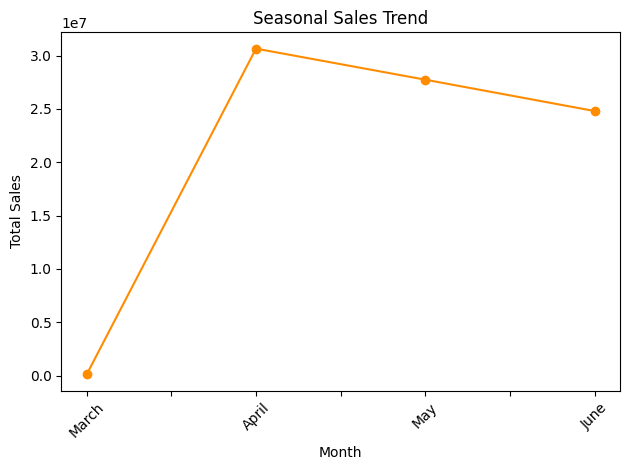

In [24]:
seasonal_sales.plot(kind='line', marker='o', title='Seasonal Sales Trend', color='darkorange')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Insight-- April recorded the highest sales, while March had the lowest.
Sales declined slightly after April but remained stable.
Seasonal trends can guide inventory planning and marketing campaigns.

In [37]:
## Calculating the average order value to understand spending behavior
average_order_value = df["Amount"].mean()
print("Average Order Value (AOV):", round(average_order_value,2))

Average Order Value (AOV): 645.92


Key Insight-- The average customer spends about ₹646 on each order. This shows that customers make moderately priced purchases, and the business can encourage higher spending through discounts, bundles, or product recommendations.

#### Customer Insight Analysis

ship-state
MAHARASHTRA       14050452.14
KARNATAKA         11041190.37
TELANGANA          7333985.65
UTTAR PRADESH      7231934.08
TAMIL NADU         6921209.11
DELHI              4469778.97
KERALA             4092192.58
WEST BENGAL        3758100.44
ANDHRA PRADESH     3446162.72
HARYANA            3018419.99
Name: Amount, dtype: float64


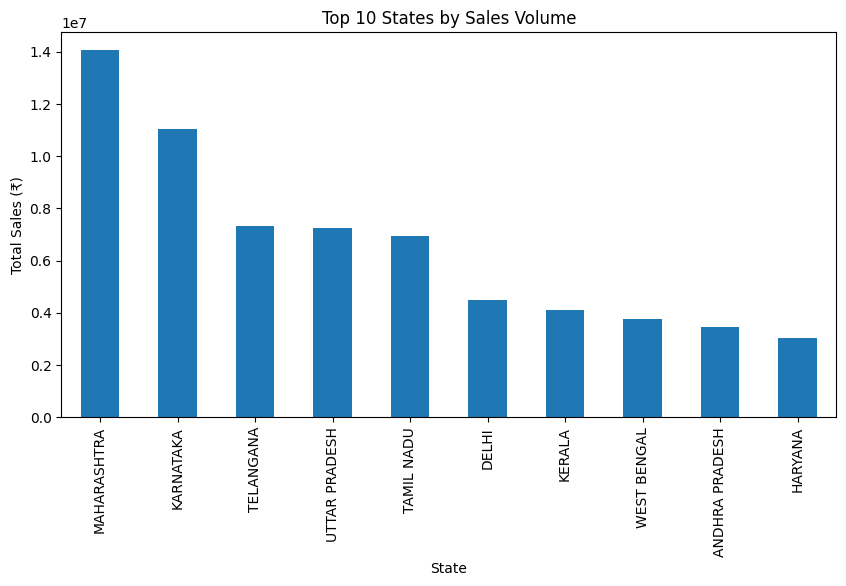

In [40]:
## Identifying top-performing locations based on sales volume.
state_sales = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False)
top_10_states = state_sales.head(10)
print(top_10_states)


plt.figure(figsize=(10,5))
top_10_states.plot(kind="bar")
plt.title("Top 10 States by Sales Volume")
plt.xlabel("State")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=90)
plt.show()

ship-city
BENGALURU    7167740.99
HYDERABAD    5227277.82
MUMBAI       3859728.80
NEW DELHI    3821817.78
CHENNAI      3273076.74
PUNE         2457729.18
KOLKATA      1497258.87
GURUGRAM     1272493.74
THANE        1061225.29
LUCKNOW       996846.34
Name: Amount, dtype: float64


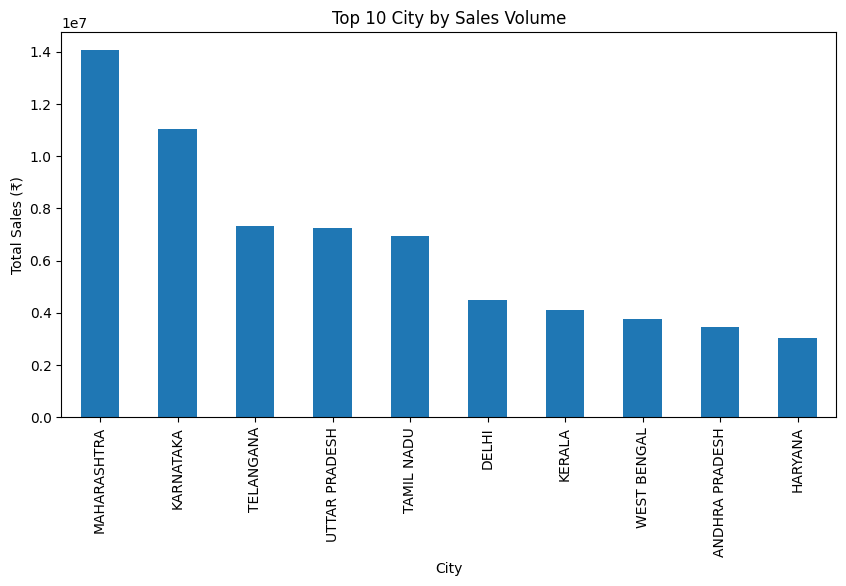

In [39]:
city_sales = df.groupby("ship-city")["Amount"].sum().sort_values(ascending=False)
top_10_city = city_sales.head(10)
print(top_10_city)


plt.figure(figsize=(10,5))
top_10_states.plot(kind="bar")
plt.title("Top 10 City by Sales Volume")
plt.xlabel("City")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=90)
plt.show()

In [48]:
## 2.Analyzing order cancellation trends

total_orders = df['Order ID'].nunique()
cancelled_orders = df[df['Status']== "Cancelled"]['Order ID'].nunique()
cancellation_rate = (cancelled_orders / total_orders) * 100

print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Cancellation Rate: 14.29 %


Month
March      18
April    7137
May      5880
June     5303
dtype: int64


/tmp/ipykernel_58/1368106497.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_trend = (df[df["Status"]=="Cancelled"].groupby("Month").size())


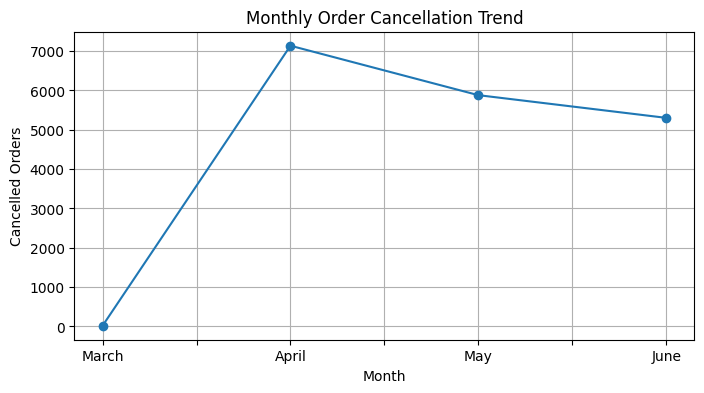

In [50]:
df['Month'] = pd.to_datetime(df['Date']).dt.month_name()
df["Month"] = df["Date"].dt.month_name()
month_order = ["March","April","May","June"]
df["Month"] = pd.Categorical(df["Month"],categories=month_order,ordered=True)
cancel_trend = (df[df["Status"]=="Cancelled"].groupby("Month").size())
print(cancel_trend)

cancel_trend.plot(kind="line", marker="o", figsize=(8,4))
plt.title("Monthly Order Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancelled Orders")
plt.grid(True)
plt.show()

Key Insight-- Order cancellations peaked in April (7,137 orders) and then steadily declined in May (5,880) and June (5,303), indicating an improvement in order fulfillment or customer purchase completion over time. The very low cancellations in March (18) are likely due to the dataset containing only a small number of records for that month.

B2B
False    128071
True        871
Name: count, dtype: int64


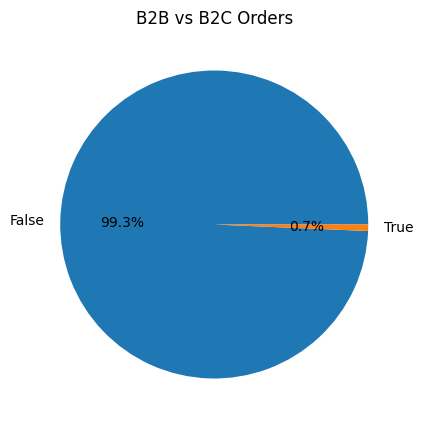

In [52]:
## Differentiating B2B vs. B2C customer behavior for targeted marketing.

# no.of orders B2B VS B2C

customer_type = df["B2B"].value_counts()
print(customer_type)

customer_type.plot( kind="pie",autopct="%1.1f%%",figsize=(5,5))
plt.title("B2B vs B2C Orders")
plt.ylabel("")
plt.show()

Key Insight-- B2C customers account for 99.3% of all orders, while B2B customers contribute only 0.7%, indicating that the business primarily serves individual consumers. This suggests greater opportunities for targeted B2B growth strategies.

B2B
False    645.559456
True     698.232824
Name: Amount, dtype: float64


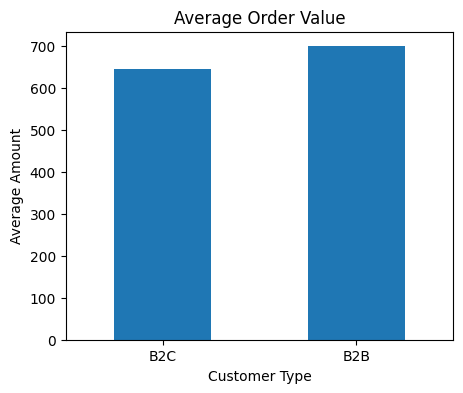

In [53]:
# average order values
aov = df.groupby("B2B")["Amount"].mean()
print(aov)

aov.plot(kind="bar", figsize=(5,4))
plt.title("Average Order Value")
plt.xlabel("Customer Type")
plt.ylabel("Average Amount")
plt.xticks([0,1],["B2C","B2B"], rotation=0)
plt.show()

Key Insight-- B2B customers have a higher average order value (₹698.23) than B2C customers (₹645.59), indicating that businesses tend to place higher-value orders despite representing a much smaller share of total orders.

B2B
False    82677445.15
True       608160.79
Name: Amount, dtype: float64


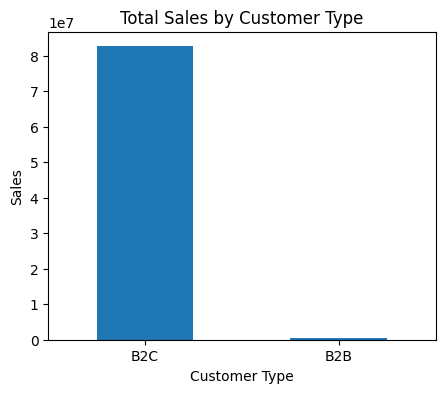

In [54]:
# toatl sales
sales = df.groupby("B2B")["Amount"].sum()
print(sales)

sales.plot(kind="bar", figsize=(5,4))
plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Sales")
plt.xticks([0,1],["B2C","B2B"], rotation=0)
plt.show()

Key Insight-- B2C customers generated the vast majority of total sales (₹82.77 million), while B2B customers contributed only ₹0.69 million. This is primarily because B2C orders account for over 99% of all transactions.

Status  Cancelled    Shipped
B2B                         
False   14.261621  60.304050
True     8.381171  60.964409


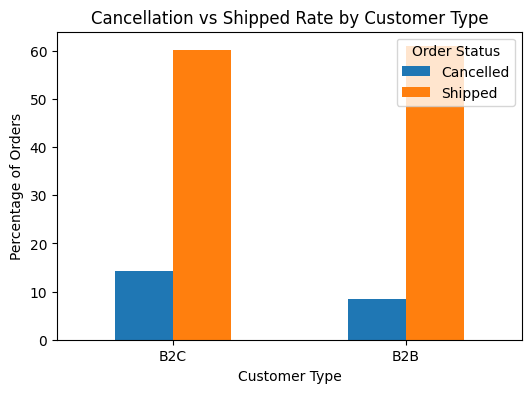

In [55]:
# cancellation rate

cancel_rate = ( pd.crosstab(df["B2B"], df["Status"], normalize="index") * 100)
print(cancel_rate[["Cancelled", "Shipped"]])
cancel_rate[["Cancelled", "Shipped"]].plot(kind="bar",figsize=(6,4))

plt.title("Cancellation vs Shipped Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Percentage of Orders")
plt.xticks([0,1], ["B2C", "B2B"], rotation=0)
plt.legend(title="Order Status")
plt.show()

Key Insight-- B2C customers account for the majority of both shipped and cancelled orders because they represent over 99% of all transactions. Despite the large difference in order volume, both B2B and B2C customers exhibit a similar order fulfillment pattern, with most orders being successfully shipped and relatively few being cancelled.

In [ ]:
# average quantity purchase
qty = df.groupby("B2B")["Qty"].mean()

print(qty)

qty.plot(kind="bar", figsize=(5,4))
plt.title("Average Quantity Purchased")
plt.xlabel("Customer Type")
plt.ylabel("Average Quantity")
plt.xticks([0,1],["B2C","B2B"], rotation=0)
plt.show()

Key Insight-- B2B customers purchase slightly more items per order (0.97 units) than B2C customers (0.90 units). Although the difference is small, it suggests that B2B customers tend to place marginally larger orders on average.

#### Logistics & Fulfillment Optimizations

ship-service-level
Expedited    88589
Standard     40353
Name: count, dtype: int64


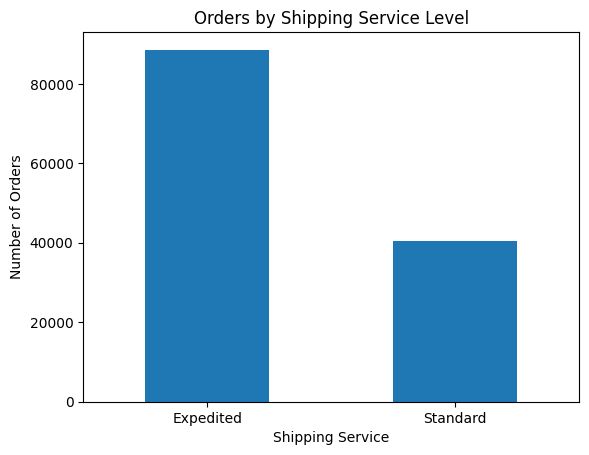

In [63]:
## 1.Addressing shipping delays by calculating average shipping times.
shipping_service = df["ship-service-level"].value_counts()
print(shipping_service)

shipping_service.plot(kind="bar")

plt.title("Orders by Shipping Service Level")
plt.xlabel("Shipping Service")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

Fulfilment
Amazon      89672
Merchant    39270
Name: count, dtype: int64


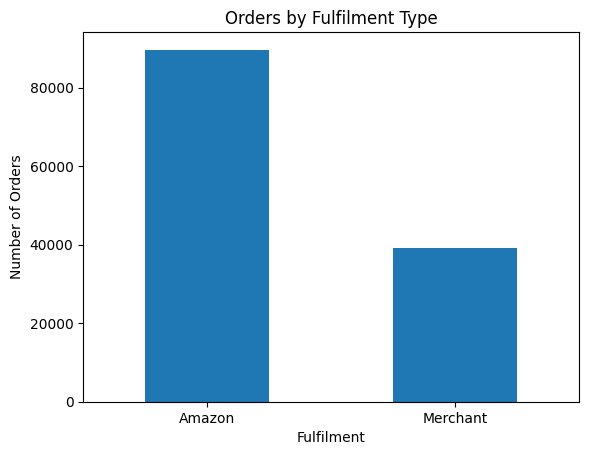

In [65]:
## 2.Comparing orders fulfilled by Amazon vs. Merchant fulfillment.

# Count of Orders (Amazon vs. Merchant fulfillment)
fulfilment_count = df["Fulfilment"].value_counts()
print(fulfilment_count)

fulfilment_count.plot(kind="bar")

plt.title("Orders by Fulfilment Type")
plt.xlabel("Fulfilment")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

Status      Cancelled  Pending  Pending - Waiting for Pick Up  Shipped  \
Fulfilment                                                               
Amazon          11476      415                              0    77762   
Merchant         6862      243                            281        1   

Status      Shipped - Damaged  Shipped - Delivered to Buyer  \
Fulfilment                                                    
Amazon                      0                            11   
Merchant                    1                         28760   

Status      Shipped - Lost in Transit  Shipped - Out for Delivery  \
Fulfilment                                                          
Amazon                              0                           0   
Merchant                            5                          35   

Status      Shipped - Picked Up  Shipped - Rejected by Buyer  \
Fulfilment                                                     
Amazon                        0              

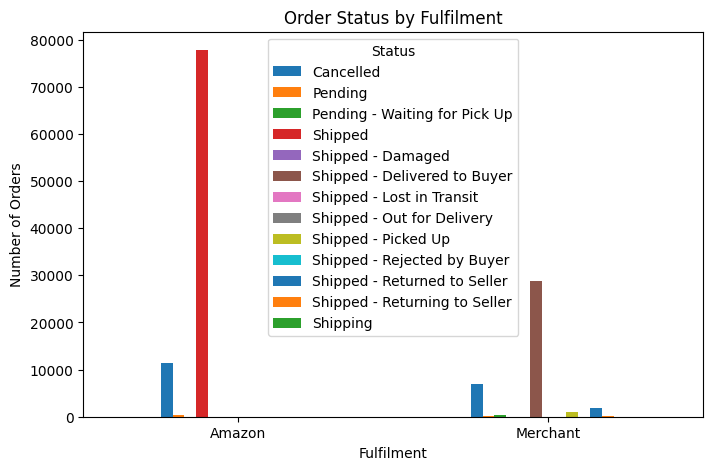

In [67]:
# Compare Order Status (Amazon vs. Merchant fulfillment)

comparison = pd.crosstab(df["Fulfilment"], df["Status"])
print(comparison)

comparison.plot(kind="bar", figsize=(8,5))

plt.title("Order Status by Fulfilment")
plt.xlabel("Fulfilment")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()


Fulfilment
Amazon      11476
Merchant     6862
Name: count, dtype: int64


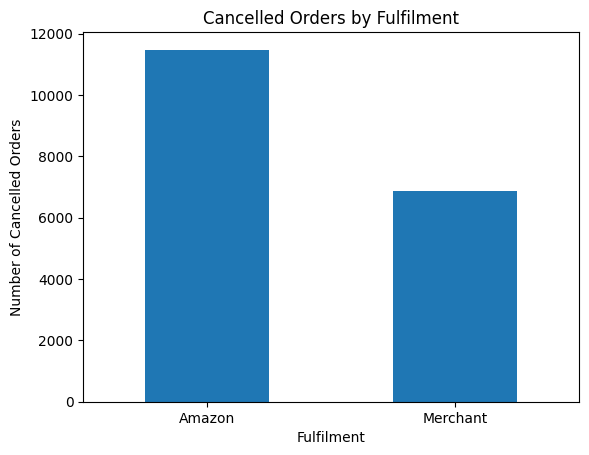

In [69]:
## 3. Improving Order Processing for Faster Deliveries.
# Cancellation by fulfillment.

cancelled = df[df["Status"] == "Cancelled"]
cancelled_by_fulfilment = cancelled["Fulfilment"].value_counts()
print(cancelled_by_fulfilment)

cancelled_by_fulfilment.plot(kind="bar")

plt.title("Cancelled Orders by Fulfilment")
plt.xlabel("Fulfilment")
plt.ylabel("Number of Cancelled Orders")
plt.xticks(rotation=0)
plt.show()

In [71]:
# Shipping Service Used in Cancelled Orders

cancelled_service = pd.crosstab(cancelled["ship-service-level"],cancelled["Status"])

print(cancelled_service)

Status              Cancelled
ship-service-level           
Expedited               11428
Standard                 6910


#### Product Management and Inventory Optimization

Category
Set              45286
kurta            45047
Western Dress    13943
Top               9902
Ethnic Dress      1052
Blouse             864
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64


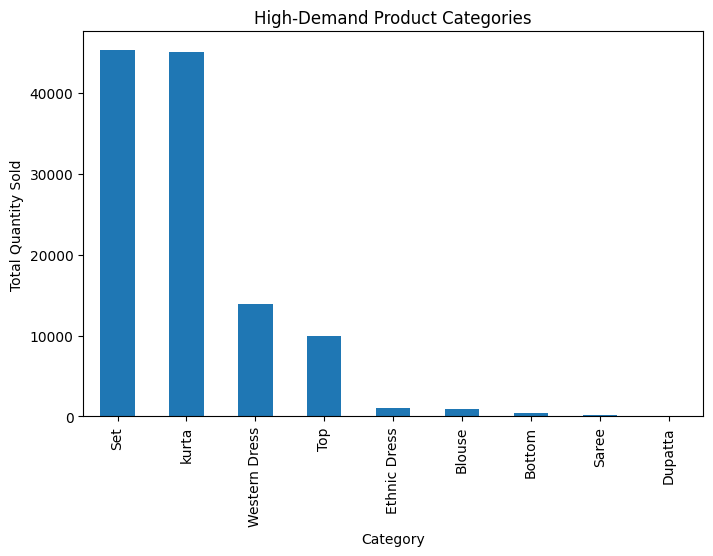

In [74]:
## 1.Identifying High-Demand Product Categories
category_demand = df.groupby("Category")["Qty"].sum().sort_values(ascending=False)
print(category_demand)


category_demand.plot(kind="bar", figsize=(8,5))

plt.title("High-Demand Product Categories")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=90)
plt.show()

In [76]:
## 2. Analyzing the Average Quantity Ordered for Efficient Stock Management
average_qty = df["Qty"].mean()
print("Average Quantity Ordered:", average_qty)

Average Quantity Ordered: 0.904647050611903


In [77]:
# Average Quantity by Category
avg_qty_category = df.groupby("Category")["Qty"].mean().sort_values(ascending=False)

print(avg_qty_category)

Category
Dupatta          1.000000
Blouse           0.933045
Top              0.932304
Saree            0.926829
Ethnic Dress     0.908463
Bottom           0.904545
kurta            0.903415
Set              0.900820
Western Dress    0.899839
Name: Qty, dtype: float64


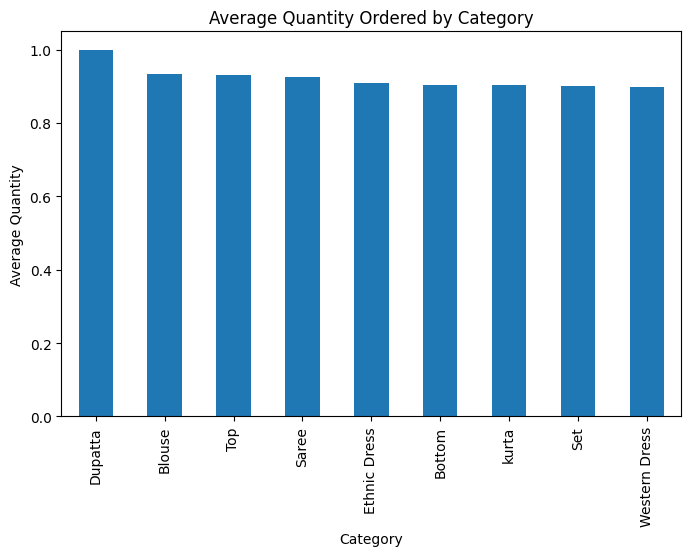

In [79]:
avg_qty_category.plot(kind="bar", figsize=(8,5))

plt.title("Average Quantity Ordered by Category")
plt.xlabel("Category")
plt.ylabel("Average Quantity")
plt.xticks(rotation=90)
plt.show()

In [80]:
##  3.Enhancing Inventory Control to Prevent Stockouts or Overstocking
# Total Quantity by SKU
sku_demand = df.groupby("SKU")["Qty"].sum().sort_values(ascending=False)

print(sku_demand.head(10))

SKU
JNE3797-KR-L       661
JNE3797-KR-M       561
JNE3797-KR-S       503
JNE3405-KR-L       485
J0230-SKD-M        468
J0230-SKD-S        421
JNE3797-KR-XL      416
JNE3405-KR-S       399
JNE3797-KR-XS      386
SET268-KR-NP-XL    373
Name: Qty, dtype: int64


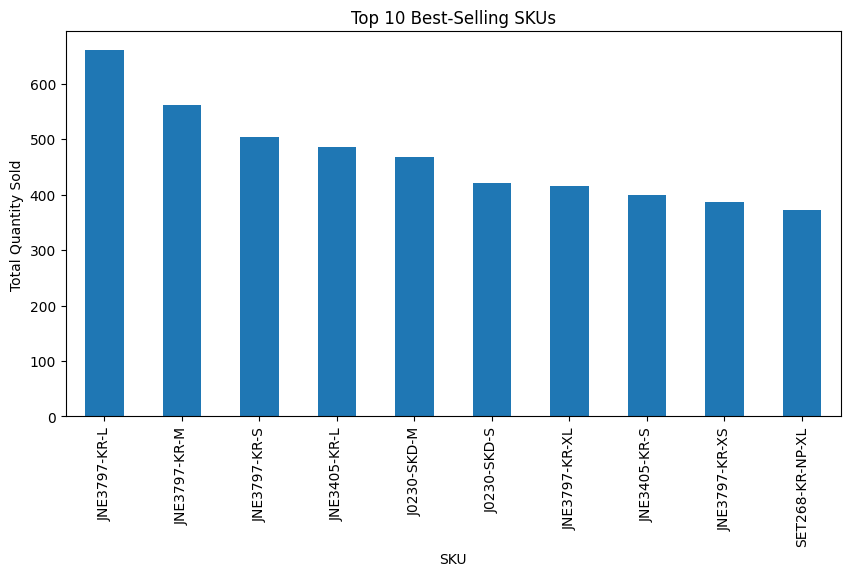

In [81]:
# Top 10 Best-Selling SKUs
top_sku = sku_demand.head(10)

top_sku.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Best-Selling SKUs")
plt.xlabel("SKU")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=90)
plt.show()

In [82]:
# Lowest-Selling SKUs
low_sku = sku_demand.tail(10)
print(low_sku)

SKU
JNE3897-KR-M          0
J0086-DR-XL           0
JNE3891-TP-XXL        0
J0184-KR-A-L          0
SET235-KR-PP-S        0
J0080-TP-L            0
JNE3364-KR-1051-XS    0
SET247-KR-SHA-XXXL    0
J0173-DR-XL           0
AN204-PURPLE-XL       0
Name: Qty, dtype: int64


####  Customer Satisfaction & Returns

In [83]:
## 1. Investigating High Return and Cancellation Rates
# Total orders
total_orders = df["Order ID"].nunique()
# Cancelled orders
cancelled_orders = df[df["Status"] == "Cancelled"]["Order ID"].nunique()
# Cancellation rate
cancellation_rate = (cancelled_orders / total_orders) * 100

print("Total Orders:", total_orders)
print("Cancelled Orders:", cancelled_orders)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Total Orders: 120352
Cancelled Orders: 17196
Cancellation Rate: 14.29 %


In [86]:
#Count Of Order Status
status_count = df["Status"].value_counts()
print(status_count)

Status
Shipped                          77763
Shipped - Delivered to Buyer     28771
Cancelled                        18338
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


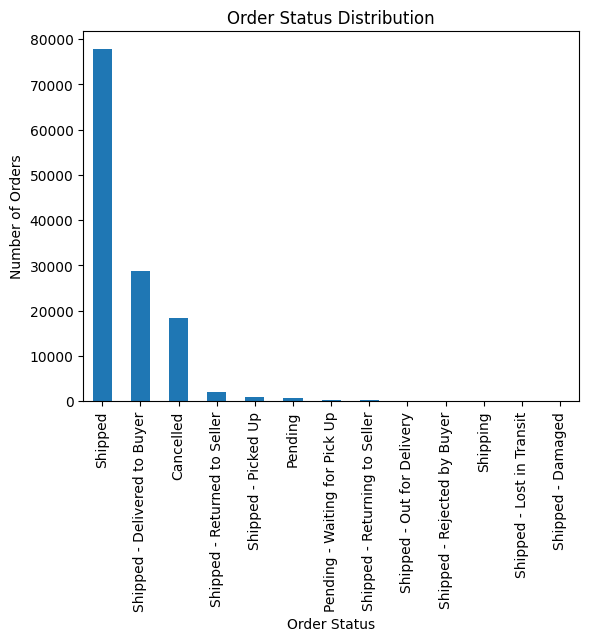

In [88]:
#Visualization
status_count.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.show()

Category
Set              7337
kurta            7257
Western Dress    2125
Top              1276
Ethnic Dress      146
Blouse            116
Bottom             60
Saree              21
Name: count, dtype: int64


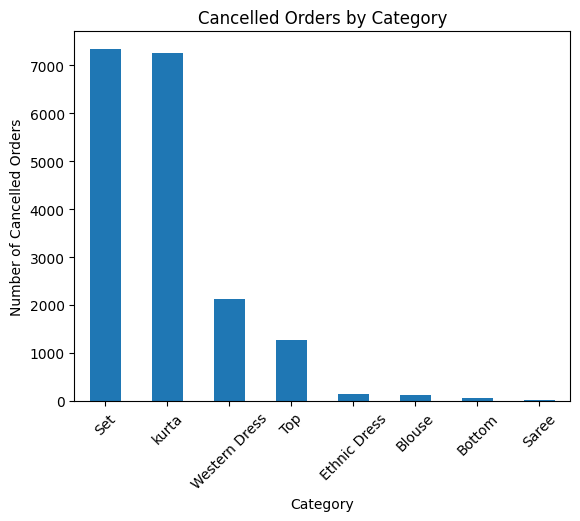

In [90]:
## 2.Identifying problematic products/categories to enhance quality.
# Cancelled Order By Category

cancelled = df[df["Status"] == "Cancelled"]
cancelled_category = cancelled["Category"].value_counts()

print(cancelled_category)

#Visualization
cancelled_category.plot(kind="bar")

plt.title("Cancelled Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Cancelled Orders")
plt.xticks(rotation=45)
plt.show()

SKU
JNE3797-KR-L      128
JNE3797-KR-M      107
JNE3797-KR-S       99
JNE3405-KR-L       86
J0230-SKD-M        73
SET268-KR-NP-S     71
JNE3797-KR-XL      69
J0003-SET-S        66
JNE3405-KR-S       65
JNE3797-KR-XS      64
Name: count, dtype: int64


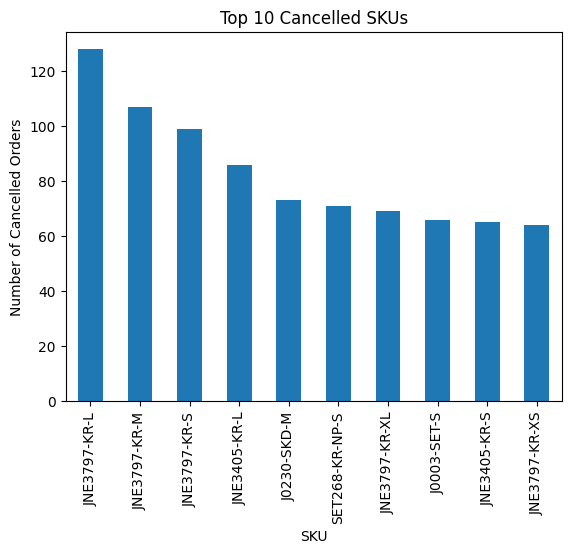

In [92]:
## Order Cancelled by SKU
cancelled_sku = cancelled["SKU"].value_counts()
print(cancelled_sku.head(10))

# Visualization
cancelled_sku.head(10).plot(kind="bar")

plt.title("Top 10 Cancelled SKUs")
plt.xlabel("SKU")
plt.ylabel("Number of Cancelled Orders")
plt.xticks(rotation=90)
plt.show()

In [93]:
## 3.Improving Customer Experience Through Better Service Policies
#Cancelled bby fulfillment type
fulfilment_cancel = pd.crosstab(df["Fulfilment"], df["Status"])
print(fulfilment_cancel)

Status      Cancelled  Pending  Pending - Waiting for Pick Up  Shipped  \
Fulfilment                                                               
Amazon          11476      415                              0    77762   
Merchant         6862      243                            281        1   

Status      Shipped - Damaged  Shipped - Delivered to Buyer  \
Fulfilment                                                    
Amazon                      0                            11   
Merchant                    1                         28760   

Status      Shipped - Lost in Transit  Shipped - Out for Delivery  \
Fulfilment                                                          
Amazon                              0                           0   
Merchant                            5                          35   

Status      Shipped - Picked Up  Shipped - Rejected by Buyer  \
Fulfilment                                                     
Amazon                        0              

Status              Cancelled  Pending  Pending - Waiting for Pick Up  \
ship-service-level                                                      
Expedited               11428      413                              0   
Standard                 6910      245                            281   

Status              Shipped  Shipped - Damaged  Shipped - Delivered to Buyer  \
ship-service-level                                                             
Expedited             76738                  0                            10   
Standard               1025                  1                         28761   

Status              Shipped - Lost in Transit  Shipped - Out for Delivery  \
ship-service-level                                                          
Expedited                                   0                           0   
Standard                                    5                          35   

Status              Shipped - Picked Up  Shipped - Rejected by Buyer  \
ship-

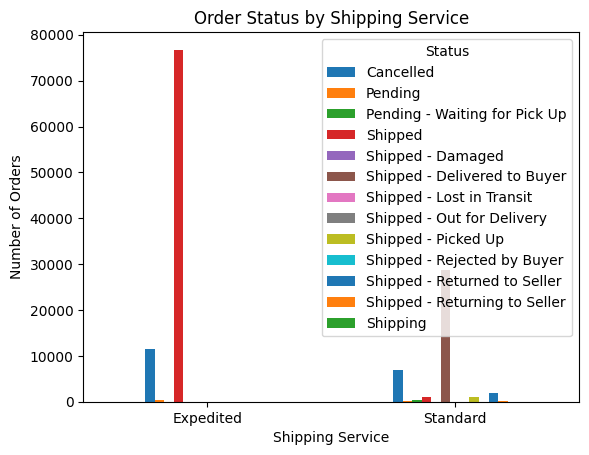

In [95]:
# Cancelled by shipping Service
service_cancel = pd.crosstab(df["ship-service-level"], df["Status"])
print(service_cancel)

# Visualization
service_cancel.plot(kind="bar")

plt.title("Order Status by Shipping Service")
plt.xlabel("Shipping Service")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

Recommendation:-
Based on the analysis, the following recommendations can improve business performance:

1.Maintain sufficient stock for high-demand categories and best-selling SKUs.  
2.Reduce cancellations by improving inventory availability and order processing. 
3.Promote products that generate the highest sales through targeted marketing campaigns. 
4.Review low-selling products and optimize inventory to reduce overstocking. 
5.Strengthen fulfilment and shipping processes to improve delivery efficiency. 
6.Continuously monitor key business metrics using dashboards for informed decision-making.

Conclusion:-
This exploratory data analysis provides valuable insights into sales performance, product demand, inventory management, logistics, and customer satisfaction. The analysis identified top-selling categories, average order quantities, cancellation trends, fulfilment performance, and high-performing locations. These findings can help the business improve inventory planning, optimize logistics, reduce cancellations, and enhance the overall customer experience. By making data-driven decisions and regularly tracking key performance indicators, the company can improve operational efficiency, increase customer satisfaction, and achieve sustainable business growth.